# Olympics Data Analysis Using Machine Learning

## Objective
1. Analyze medal distribution across countries and years.
2. Identify top-performing countries and athletes.
3. Study gender participation in Olympic events.
4. Build machine learning models to predict medal categories.


# Problem Statement

The Olympic Games generate large amounts of data related to athletes, countries, sports, and medal achievements. Analyzing this data helps identify performance trends, participation patterns, and factors contributing to success. This project aims to perform exploratory data analysis and build machine learning models to predict medal outcomes based on Olympic event characteristics.

# Tools Used

## Python

## Pandas

## NumPy

## Matplotlib

## Seaborn

## Scikit-learn

ML MODELS:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier



## Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## Step 2: Load Dataset

In [ ]:
df = pd.read_csv('/content/Summer-Olympic-medals-1976-to-2008.csv', encoding='latin1')
df.head()

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
0,Montreal,1976.0,Aquatics,Diving,3m springboard,"KÖHLER, Christa",Women,GDR,East Germany,W,Silver
1,Montreal,1976.0,Aquatics,Diving,3m springboard,"KOSENKOV, Aleksandr",Men,URS,Soviet Union,M,Bronze
2,Montreal,1976.0,Aquatics,Diving,3m springboard,"BOGGS, Philip George",Men,USA,United States,M,Gold
3,Montreal,1976.0,Aquatics,Diving,3m springboard,"CAGNOTTO, Giorgio Franco",Men,ITA,Italy,M,Silver
4,Montreal,1976.0,Aquatics,Diving,10m platform,"WILSON, Deborah Keplar",Women,USA,United States,W,Bronze


## Step 3: Dataset Overview

In [ ]:
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15433 entries, 0 to 15432
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   City          15316 non-null  object 
 1   Year          15316 non-null  float64
 2   Sport         15316 non-null  object 
 3   Discipline    15316 non-null  object 
 4   Event         15316 non-null  object 
 5   Athlete       15316 non-null  object 
 6   Gender        15316 non-null  object 
 7   Country_Code  15316 non-null  object 
 8   Country       15316 non-null  object 
 9   Event_gender  15316 non-null  object 
 10  Medal         15316 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.3+ MB


((15433, 11), None)

## Step 4: Data Cleaning

In [ ]:
print(df.isnull().sum())
df = df.dropna(how='all')
df = df.drop(columns=['Event_gender','Country_Code'], errors='ignore')
df['Year'] = df['Year'].astype(int)


City            117
Year            117
Sport           117
Discipline      117
Event           117
Athlete         117
Gender          117
Country_Code    117
Country         117
Event_gender    117
Medal           117
dtype: int64


### Interpretation

The dataset was cleaned by removing unnecessary columns and handling missing records. Event_gender and Country_Code were removed because similar information already exists in Gender and Country columns.


## Step 5: Top 10 Countries by Medal Count

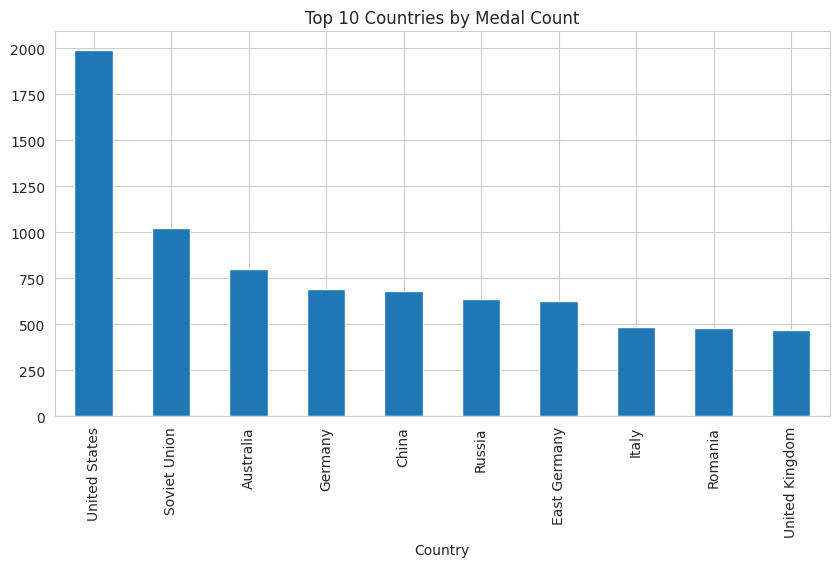

In [ ]:
medals_by_country = df.groupby('Country')['Medal'].count().sort_values(ascending=False)

plt.figure(figsize=(10,5))
medals_by_country.head(10).plot(kind='bar')
plt.title('Top 10 Countries by Medal Count')
plt.show()


### What this chart shows

This visualization displays the countries that have won the highest number of Olympic medals between 1976 and 2008.

### Key Findings

- A few countries dominate Olympic medal rankings.
- Leading nations consistently outperform others across multiple sports.

### Business Insight

Countries with strong sports infrastructure and athlete development programs tend to achieve greater Olympic success.


## Step 6: Medals Won Over the Years

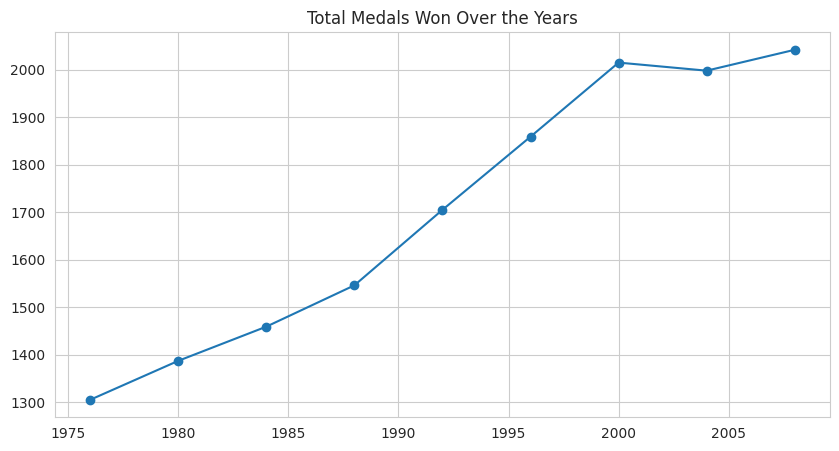

In [ ]:
medals_over_years = df.groupby('Year')['Medal'].count()

plt.figure(figsize=(10,5))
plt.plot(medals_over_years.index, medals_over_years.values, marker='o')
plt.title('Total Medals Won Over the Years')
plt.show()


### What this chart shows

The chart illustrates how Olympic medal counts changed between 1976 and 2008.

### Key Findings

- Medal opportunities generally increased over time.
- Growth reflects expansion of Olympic events and participation.

### Business Insight

The Olympic Games have become increasingly global, attracting more athletes and countries over time.


## Step 7: Gender Distribution

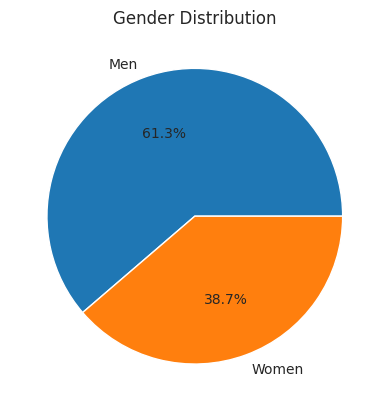

In [ ]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()


### What this chart shows

This chart presents the distribution of male and female athletes in Olympic events.

### Key Findings

- Male participation remains higher than female participation.
- Female representation has increased significantly over time.

### Business Insight

The results demonstrate progress toward gender equality within international sports competitions.


## Step 8: Top Athletes by Medal Count

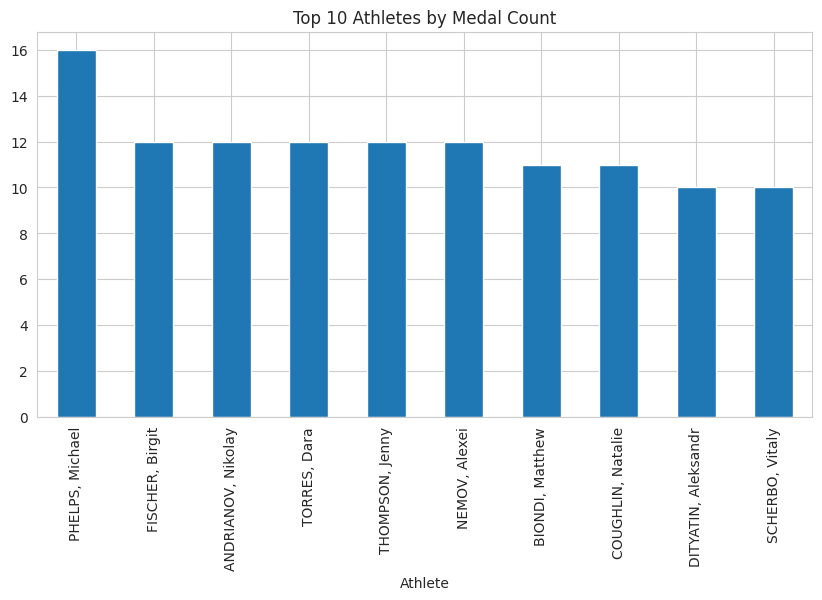

In [ ]:
athlete_medals = df.groupby('Athlete')['Medal'].count().sort_values(ascending=False)

plt.figure(figsize=(10,5))
athlete_medals.head(10).plot(kind='bar')
plt.title('Top 10 Athletes by Medal Count')
plt.show()


### What this chart shows

This visualization highlights athletes who accumulated the highest number of Olympic medals.

### Key Findings

- Elite athletes consistently appear at the top of medal rankings.
- Multiple Olympic appearances contribute to higher medal counts.

### Business Insight

Long-term athlete development programs play a crucial role in achieving sustained Olympic success.


## Step 9: Machine Learning Preparation

In [ ]:
data = df.copy()

encoders = {}
for col in ['Country','Sport','Gender','Discipline','Medal']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    encoders[col] = le

X = data[['Country','Sport','Gender','Discipline']]
y = data['Medal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Step 10: Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)

print('Accuracy:', accuracy_score(y_test, lr_pred))


Accuracy: 0.3472584856396867


### Interpretation

Logistic Regression serves as a baseline model for predicting medal categories. Its performance provides a benchmark against which more advanced models can be evaluated.


## Step 11: Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)

print('Accuracy:', accuracy_score(y_test, dt_pred))


Accuracy: 0.5372062663185379


## Step 12: Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Accuracy: 0.5345953002610966
              precision    recall  f1-score   support

           0       0.53      0.55      0.54      1027
           1       0.54      0.57      0.56      1043
           2       0.52      0.48      0.50       994

    accuracy                           0.53      3064
   macro avg       0.53      0.53      0.53      3064
weighted avg       0.53      0.53      0.53      3064



### Interpretation

Random Forest combines multiple decision trees and generally provides better predictive performance. The model captures complex relationships between country, sport, gender, and medal outcomes.


# Conclusion

This project successfully analyzed the Summer Olympics medal dataset from 1976 to 2008 using Exploratory Data Analysis (EDA) and Machine Learning techniques. The analysis helped identify top-performing countries, successful athletes, medal distribution patterns, and gender participation trends across different Olympic events. Various visualizations provided valuable insights into how Olympic performance evolved over the years. Additionally, a machine learning classification model was developed to predict medal outcomes based on factors such as country, sport, discipline, and gender. Overall, the project demonstrates how data analytics and machine learning can be used to extract meaningful insights from historical sports data and support predictive decision-making.

# Future Improvements

The project can be further enhanced by implementing advanced machine learning models such as Random Forest, XGBoost, and Gradient Boosting to improve prediction accuracy. Additional features like athlete age, previous performance records, host country advantage, and sports funding can be incorporated for deeper analysis. Future work may also include adding recent Olympic datasets, performing feature engineering and hyperparameter tuning, and developing interactive dashboards using Power BI or Tableau. These improvements can provide more accurate predictions and richer insights into Olympic performance trends.